In [1]:
from utils.text_utils import *
from utils import data_analysis_utils as data

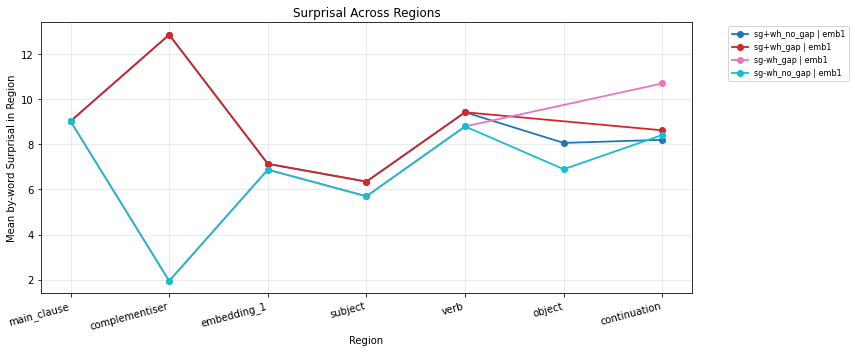

In [3]:
configs = [
    {'sentence_group': 2, 'condition': '+wh_no_gap', 'levels_of_embedding': 1},
    {'sentence_group': 2, 'condition': '+wh_gap',    'levels_of_embedding': 1},
    {'sentence_group': 2, 'condition': '-wh_gap',    'levels_of_embedding': 1},
    {'sentence_group': 2, 'condition': '-wh_no_gap', 'levels_of_embedding': 1},
]

data.plot_surprisal_lines('../data/model_outputs/gpt2_pilot_object_gap_gender_change_stimuli_with_surprisals.csv', configs, save_path="../data/images/s_g1_em1.png")

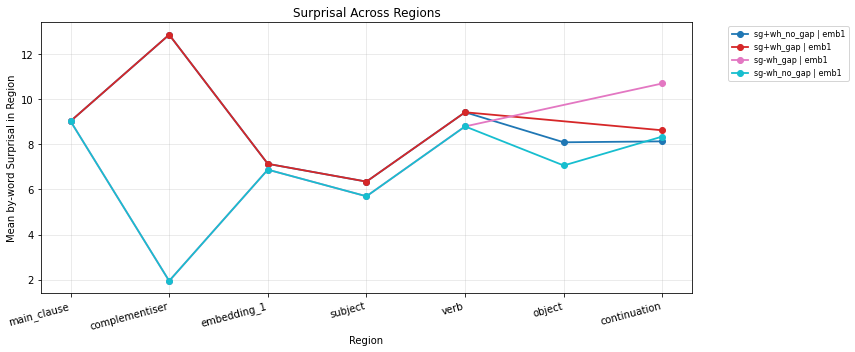

In [6]:
configs = [
    {'sentence_group': 2, 'condition': '+wh_no_gap', 'levels_of_embedding': 1},
    {'sentence_group': 2, 'condition': '+wh_gap',    'levels_of_embedding': 1},
    {'sentence_group': 2, 'condition': '-wh_gap',    'levels_of_embedding': 1},
    {'sentence_group': 2, 'condition': '-wh_no_gap', 'levels_of_embedding': 1},
]

data.plot_surprisal_lines('../data/model_outputs/gpt2_pilot_object_gaps_stimuli_with_surprisals.csv', configs, save_path="../data/images/s_g1_em1.png")

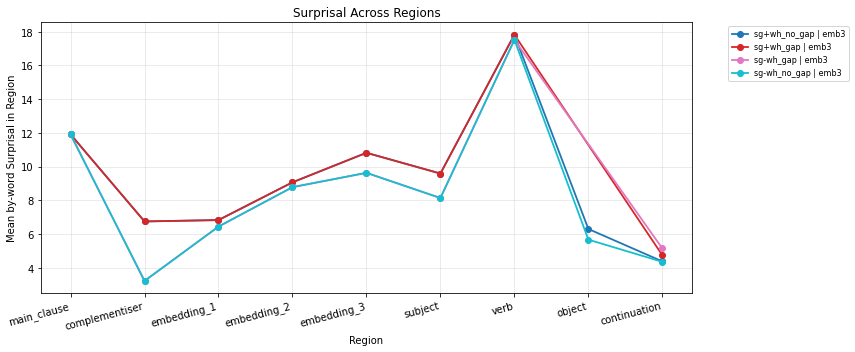

In [4]:
configs = [
    {'sentence_group': 1, 'condition': '+wh_no_gap', 'levels_of_embedding': 3},
    {'sentence_group': 1, 'condition': '+wh_gap',    'levels_of_embedding': 3},
    {'sentence_group': 1, 'condition': '-wh_gap',    'levels_of_embedding': 3},
    {'sentence_group': 1, 'condition': '-wh_no_gap', 'levels_of_embedding': 3},
]

data.plot_surprisal_lines('../data/model_outputs/gpt2_pilot_object_gaps_stimuli_with_surprisals.csv', configs, save_path="../data/images/s_g1_em3.png")

### note on comparing across gap/no gap conditions
seems like broadly speaking object surprisal is higher than continuation surprisal: unclear why but would explain current results, might be necessary to rely on global metrics or introduce some kind of norming by word frequency (dividing by context-less surprisal)?

**Wilcox 2022, wh-effect**

| | +wh | -wh |
|---|---|---|
| **+gap** | I know what the lion devoured _ at sunrise. | *I know that the lion devoured _ at sunrise. |
| **-gap** | *I know what the lion devoured a gazelle at sunrise. | I know that the lion devoured a gazelle at sunrise. |


---


**filler_offloading**

| | +gap | -gap |
|---|---|---|
| **+wh** | I know what the lion devoured _ at sunrise. | *I know what the lion devoured a gazelle at sunrise. |
| **-wh** | *I know that the lion devoured _ at sunrise. | I know that the lion devoured a gazelle at sunrise. |


=== STANDARD DEVIATIONS (Wh-Effect (GPT-2)) ===

  +gap:
    embedding 0: mean=-3.527, sd=2.177, n=3
    embedding 1: mean=-4.476, sd=1.698, n=3
    embedding 2: mean=-3.771, sd=1.715, n=3
    embedding 3: mean=-2.023, sd=0.779, n=3

  -gap:
    embedding 0: mean=4.483, sd=2.042, n=3
    embedding 1: mean=2.947, sd=0.840, n=3
    embedding 2: mean=2.167, sd=0.616, n=3
    embedding 3: mean=0.770, sd=0.412, n=3


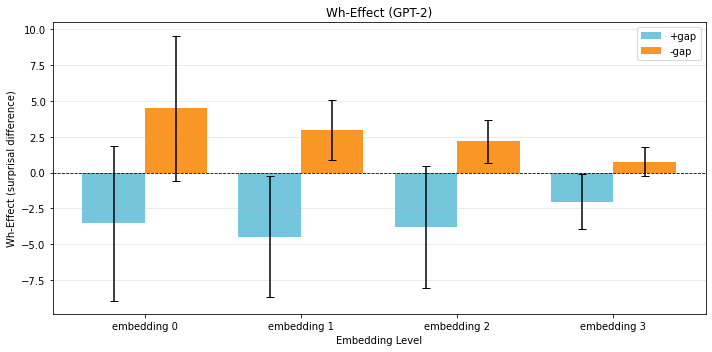


=== STANDARD DEVIATIONS (Local Filler Offloading Effect (GPT-2)) ===

  +wh:
    embedding 0: mean=-1.848, sd=3.239, n=3
    embedding 1: mean=-0.746, sd=2.625, n=3
    embedding 2: mean=0.745, sd=4.782, n=3
    embedding 3: mean=4.673, sd=5.182, n=3

  -wh:
    embedding 0: mean=6.161, sd=4.123, n=3
    embedding 1: mean=6.678, sd=4.571, n=3
    embedding 2: mean=6.684, sd=5.422, n=3
    embedding 3: mean=7.466, sd=5.819, n=3


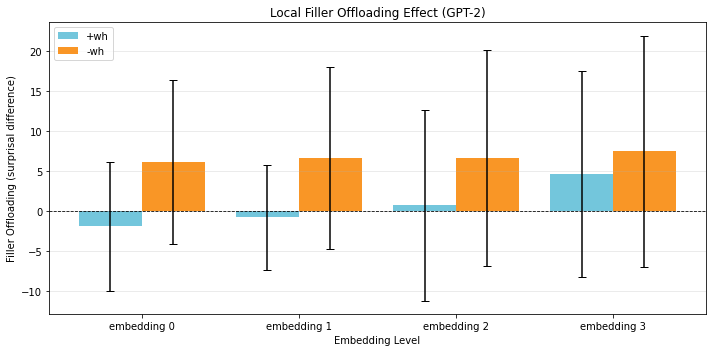

In [7]:
surprisal_df = pd.read_csv('../data/model_outputs/gpt2_pilot_object_gap_gender_change_stimuli_with_surprisals.csv')

# wh-effect plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_wh_effect,
    conditions=['gap', 'no_gap'],
    condition_labels=['+gap', '-gap'],
    title='Wh-Effect (GPT-2)',
    ylabel='Wh-Effect (surprisal difference)',
    surprisal_type="local",
    gap_type = "object"
)

# filler offloading plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_filler_offloading_effect,
    conditions=['+wh', '-wh'],
    condition_labels=['+wh', '-wh'],
    title='Local Filler Offloading Effect (GPT-2)',
    ylabel='Filler Offloading (surprisal difference)',
         surprisal_type="local",
        gap_type = "object"
)


=== STANDARD DEVIATIONS (Wh-Effect (GPT-2)) ===

  +gap:
    embedding 0: mean=-2.906, sd=2.746, n=3
    embedding 1: mean=-3.207, sd=2.563, n=3
    embedding 2: mean=-2.411, sd=2.284, n=3
    embedding 3: mean=-1.362, sd=1.354, n=3

  -gap:
    embedding 0: mean=0.900, sd=0.271, n=3
    embedding 1: mean=0.437, sd=0.199, n=3
    embedding 2: mean=0.245, sd=0.288, n=3
    embedding 3: mean=-0.017, sd=0.252, n=3


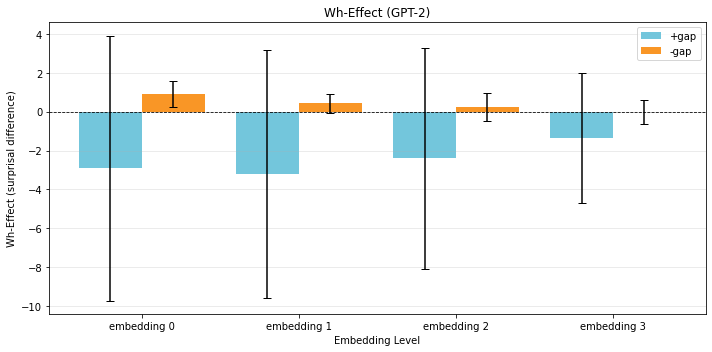


=== STANDARD DEVIATIONS (Semi-Local Filler Offloading Effect (GPT-2)) ===

  +wh:
    embedding 0: mean=-0.698, sd=0.303, n=3
    embedding 1: mean=-0.052, sd=0.897, n=3
    embedding 2: mean=0.768, sd=1.979, n=3
    embedding 3: mean=2.606, sd=3.103, n=3

  -wh:
    embedding 0: mean=3.109, sd=3.023, n=3
    embedding 1: mean=3.592, sd=3.331, n=3
    embedding 2: mean=3.424, sd=3.999, n=3
    embedding 3: mean=3.951, sd=4.242, n=3


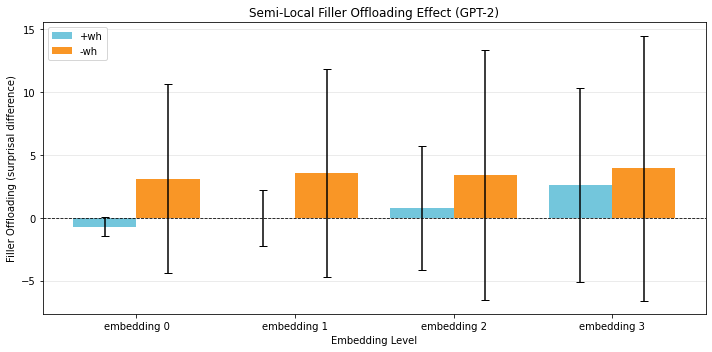

In [7]:
surprisal_df = pd.read_csv('../data/model_outputs/gpt2_pilot_object_gaps_stimuli_with_surprisals.csv')

# wh-effect plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_wh_effect,
    conditions=['gap', 'no_gap'],
    condition_labels=['+gap', '-gap'],
    title='Wh-Effect (GPT-2)',
    ylabel='Wh-Effect (surprisal difference)',
    surprisal_type="semi_local",
    gap_type = "object"
)

# filler offloading plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_filler_offloading_effect,
    conditions=['+wh', '-wh'],
    condition_labels=['+wh', '-wh'],
    title='Semi-Local Filler Offloading Effect (GPT-2)',
    ylabel='Filler Offloading (surprisal difference)',
     surprisal_type="semi_local",
    gap_type = "object"
)


=== STANDARD DEVIATIONS (Wh-Effect (GPT-2)) ===

  +gap:
    embedding 0: mean=0.351, sd=0.334, n=3
    embedding 1: mean=0.377, sd=0.170, n=3
    embedding 2: mean=0.571, sd=0.148, n=3
    embedding 3: mean=0.552, sd=0.166, n=3

  -gap:
    embedding 0: mean=1.049, sd=0.347, n=3
    embedding 1: mean=0.821, sd=0.126, n=3
    embedding 2: mean=0.796, sd=0.111, n=3
    embedding 3: mean=0.602, sd=0.122, n=3


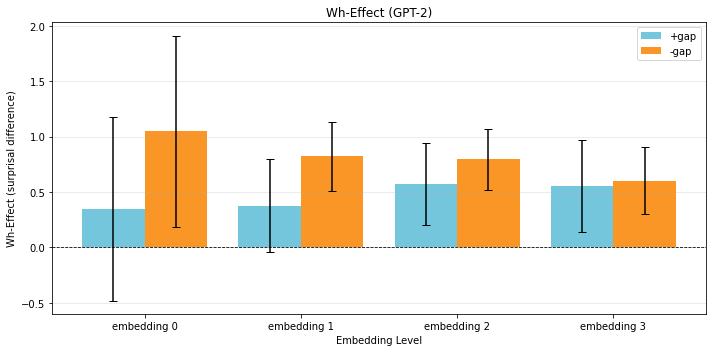


=== STANDARD DEVIATIONS (Global Filler Offloading Effect (GPT-2)) ===

  +wh:
    embedding 0: mean=-0.042, sd=0.380, n=3
    embedding 1: mean=0.053, sd=0.201, n=3
    embedding 2: mean=0.156, sd=0.034, n=3
    embedding 3: mean=0.323, sd=0.073, n=3

  -wh:
    embedding 0: mean=0.656, sd=0.116, n=3
    embedding 1: mean=0.498, sd=0.067, n=3
    embedding 2: mean=0.381, sd=0.032, n=3
    embedding 3: mean=0.374, sd=0.026, n=3


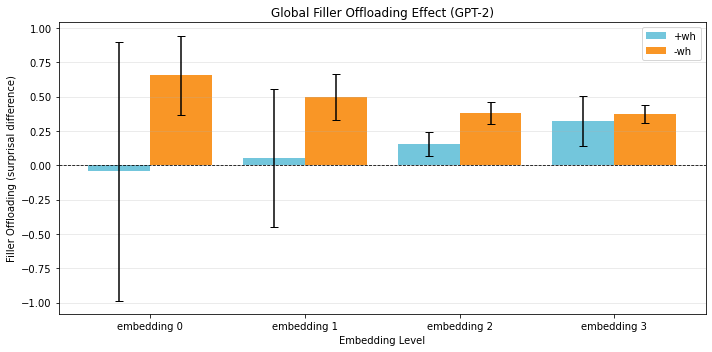

In [8]:
surprisal_df = pd.read_csv('../data/model_outputs/gpt2_pilot_object_gaps_stimuli_with_surprisals.csv')

# wh-effect plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_wh_effect,
    conditions=['gap', 'no_gap'],
    condition_labels=['+gap', '-gap'],
    title='Wh-Effect (GPT-2)',
    ylabel='Wh-Effect (surprisal difference)',
    surprisal_type="global",
    gap_type = "object"
)

# filler offloading plot
data.plot_effect_bar_chart(
    surprisal_df,
    effect_fn=data.get_filler_offloading_effect,
    conditions=['+wh', '-wh'],
    condition_labels=['+wh', '-wh'],
    title='Global Filler Offloading Effect (GPT-2)',
    ylabel='Filler Offloading (surprisal difference)',
     surprisal_type="global",
    gap_type = "object"
)

# Metrics - local surprisal
in all cases if model predicts gramaticality we would expect the left bar to be negative and the right to be positive.

##  gpt2 metrics

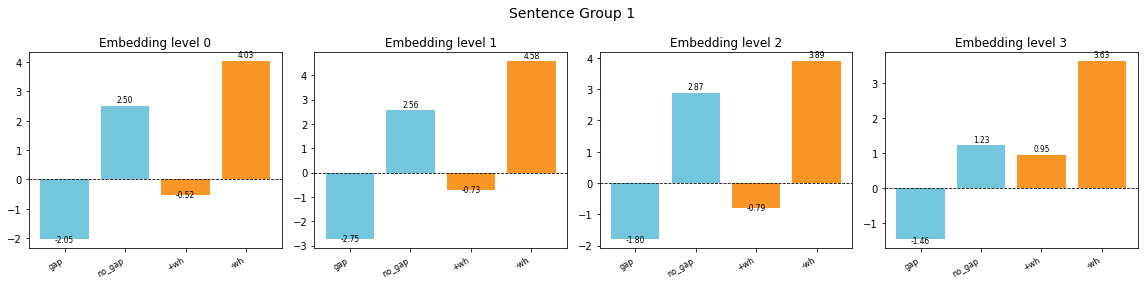

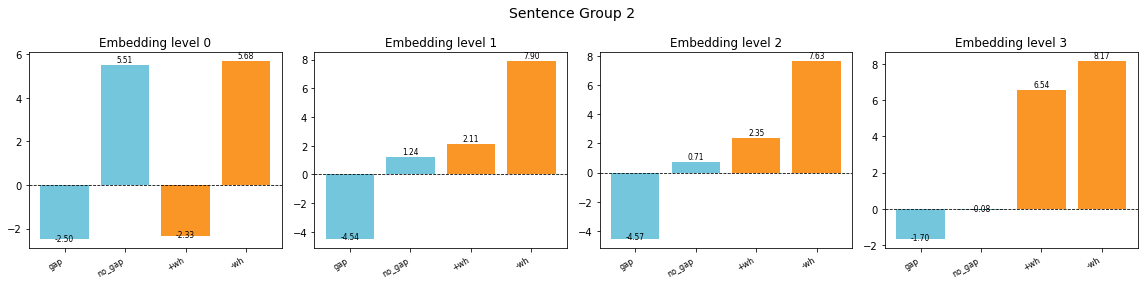

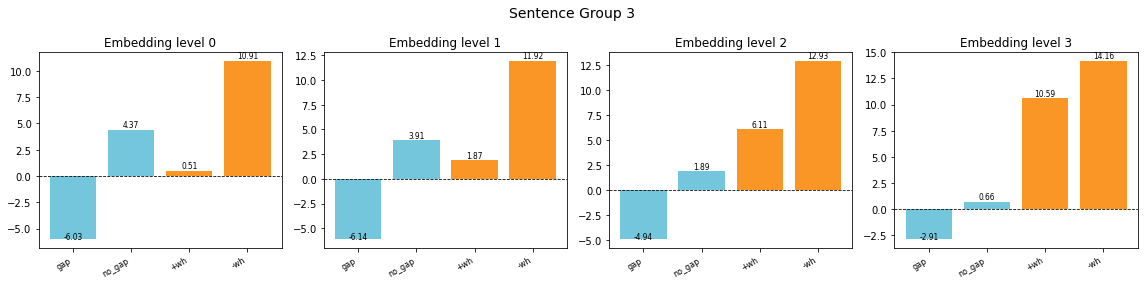

In [9]:
gpt2_df = pd.read_csv("../data/model_outputs/gpt2_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(gpt2_df, surprisal_type='local' ,
    gap_type = "object")

## ngram metrics
the only reason these are different is that in my case the preceding 5 words maybe different (comparing between filled gap and not-filled gap conditions), this isn't especially relevant

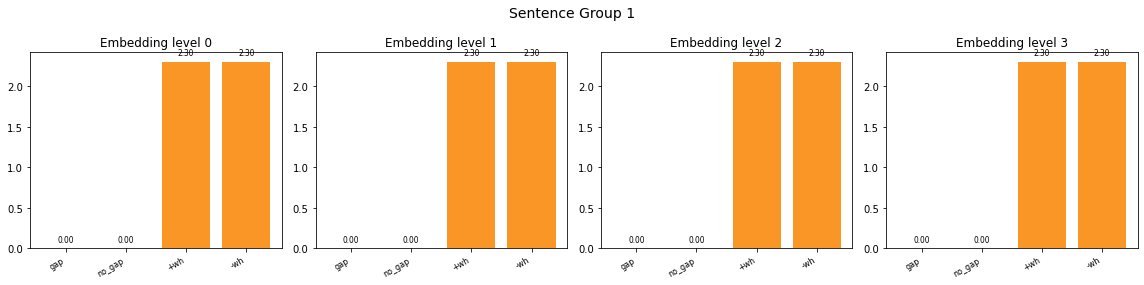

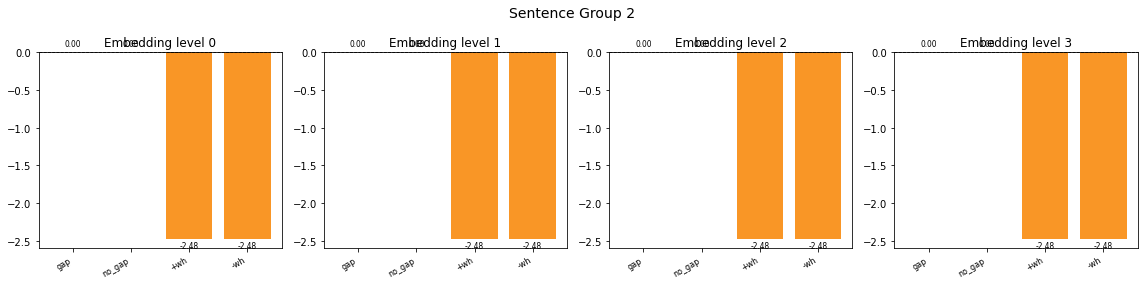

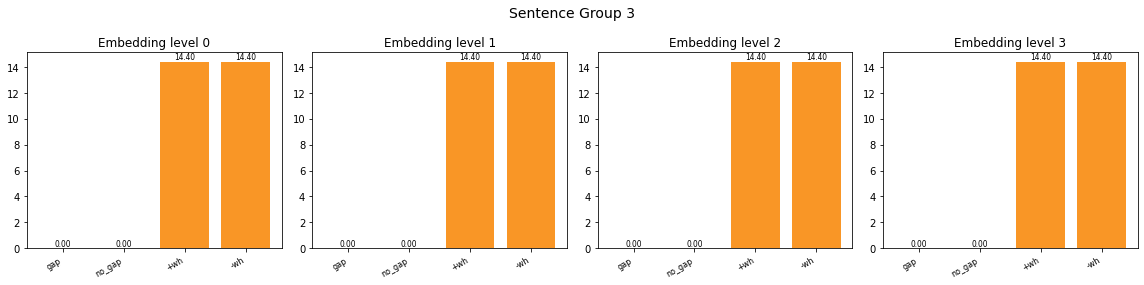

In [10]:
ngram_df = pd.read_csv("../data/model_outputs/ngram_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(ngram_df, surprisal_type='local',
    gap_type = "object")

## grnn metrics

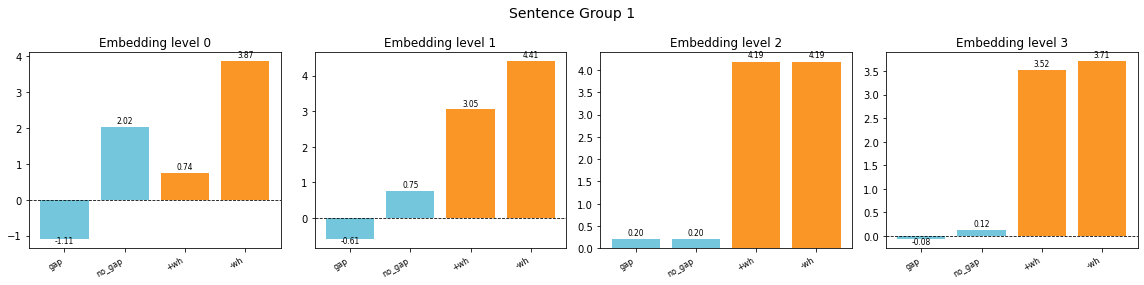

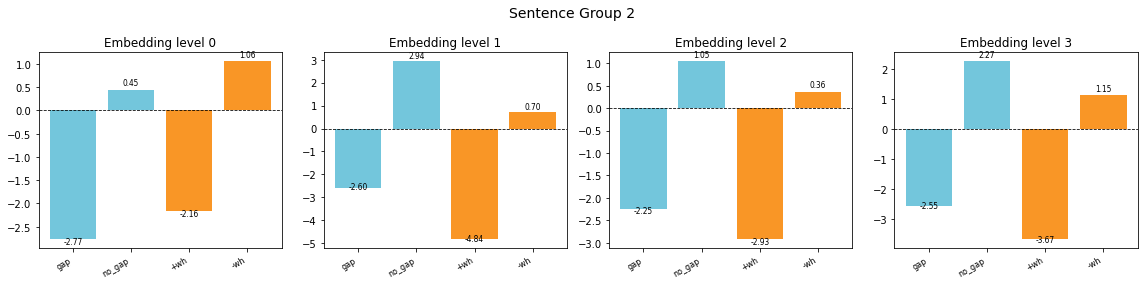

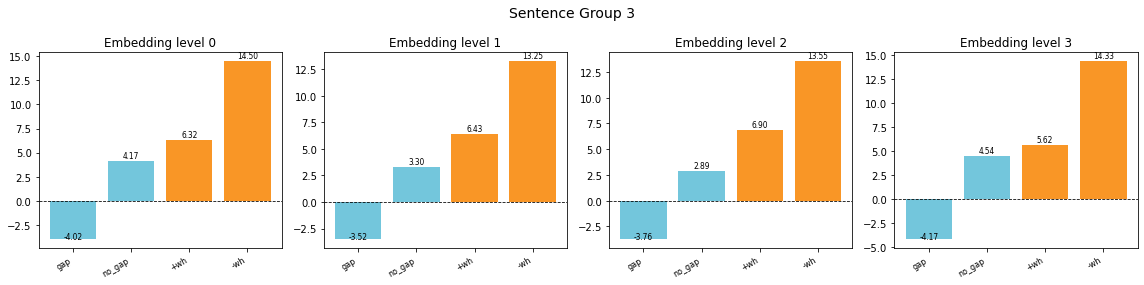

In [11]:
grnn_df = pd.read_csv("../data/model_outputs/grnn_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(grnn_df, surprisal_type='local',
    gap_type = "object")

## Metrics - multi-model

/home/marrsia/.local/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2128: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/marrsia/.local/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2129: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
/home/marrsia/.local/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2128: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/marrsia/.local/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2129: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc



=== STANDARD DEVIATIONS (Wh-effect by model and embedding level) ===

  [GPT-2]
  gap:
    embedding 0: mean=-3.527, sd=2.177, n=3
    embedding 1: mean=-4.476, sd=1.698, n=3
    embedding 2: mean=-3.771, sd=1.715, n=3
    embedding 3: mean=-2.023, sd=0.779, n=3
  no_gap:
    embedding 0: mean=4.126, sd=1.520, n=3
    embedding 1: mean=2.572, sd=1.335, n=3
    embedding 2: mean=1.822, sd=1.085, n=3
    embedding 3: mean=0.602, sd=0.654, n=3

  [GRNN]
  gap:
    embedding 0: mean=-2.633, sd=1.458, n=3
    embedding 1: mean=-2.244, sd=1.487, n=3
    embedding 2: mean=-1.934, sd=2.001, n=3
    embedding 3: mean=-2.266, sd=2.061, n=3
  no_gap:
    embedding 0: mean=2.213, sd=1.867, n=3
    embedding 1: mean=2.330, sd=1.381, n=3
    embedding 2: mean=1.379, sd=1.372, n=3
    embedding 3: mean=2.308, sd=2.210, n=3

  [ngram]
  gap:
    embedding 0: mean=0.000, sd=0.000, n=3
    embedding 1: mean=0.000, sd=0.000, n=3
    embedding 2: mean=0.000, sd=0.000, n=3
    embedding 3: mean=0.000, sd=

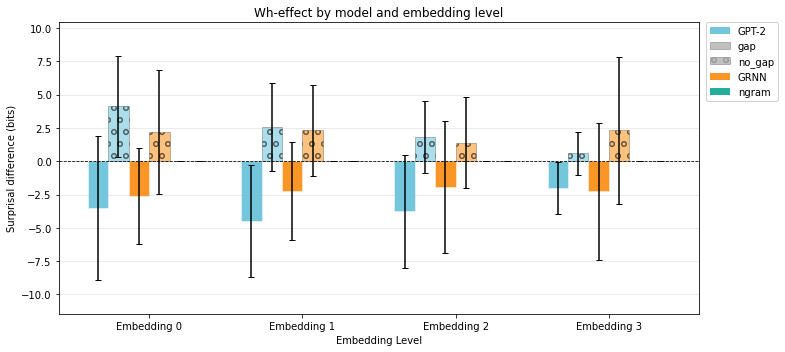

In [12]:
model_dfs = {
    "GPT-2": gpt2_df,
    "GRNN":  grnn_df,
    "ngram": ngram_df,
}

data.plot_effect_bar_chart_multi_model(
    model_dfs     = model_dfs,
    effect_fn     = data.get_wh_effect,
    conditions    = ["gap", "no_gap"],
    title         = "Wh-effect by model and embedding level",
    ylabel        = "Surprisal difference (bits)",
    surprisal_type= "local",
    gap_type      = "object",
    condition_labels = ["gap", "no_gap"],
    save_path = "../data/images/wh_effect_main.png"
)


=== STANDARD DEVIATIONS (Filler-offloading by model and embedding level) ===

  [GPT-2]
  +wh:
    embedding 0: mean=-0.776, sd=1.438, n=3
    embedding 1: mean=1.086, sd=1.573, n=3
    embedding 2: mean=2.558, sd=3.451, n=3
    embedding 3: mean=6.027, sd=4.842, n=3
  -wh:
    embedding 0: mean=6.876, sd=3.593, n=3
    embedding 1: mean=8.134, sd=3.674, n=3
    embedding 2: mean=8.151, sd=4.543, n=3
    embedding 3: mean=8.653, sd=5.282, n=3

  [GRNN]
  +wh:
    embedding 0: mean=1.630, sd=4.310, n=3
    embedding 1: mean=1.548, sd=5.785, n=3
    embedding 2: mean=2.720, sd=5.077, n=3
    embedding 3: mean=1.824, sd=4.872, n=3
  -wh:
    embedding 0: mean=6.476, sd=7.090, n=3
    embedding 1: mean=6.121, sd=6.448, n=3
    embedding 2: mean=6.034, sd=6.785, n=3
    embedding 3: mean=6.397, sd=6.992, n=3

  [ngram]
  +wh:
    embedding 0: mean=4.744, sd=8.699, n=3
    embedding 1: mean=4.744, sd=8.699, n=3
    embedding 2: mean=4.744, sd=8.699, n=3
    embedding 3: mean=4.744, sd=8.699

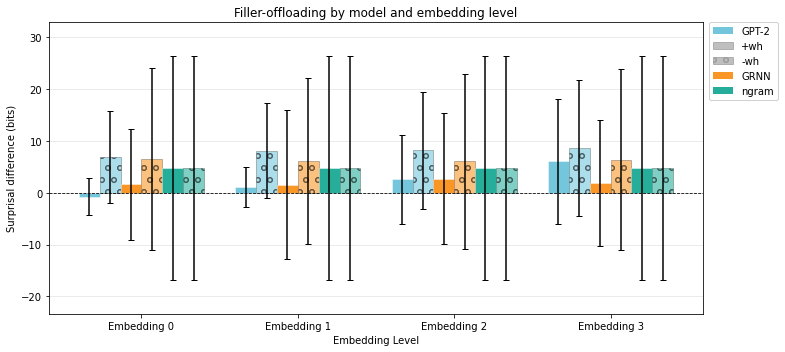

In [16]:
data.plot_effect_bar_chart_multi_model(
    model_dfs     = model_dfs,
    effect_fn     = data.get_filler_offloading_effect,
    conditions    = ["+wh", "-wh"],
    title         = "Filler-offloading by model and embedding level",
    ylabel        = "Surprisal difference (bits)",
    surprisal_type= "local",
    gap_type      = "object",
    condition_labels = ["+wh", "-wh"],
    save_path = "../data/images/fo_effect_main.png"
)

# Metrics - semi-local surprisal
in all cases if model predicts gramaticality we would expect the left bar to be negative and the right to be positive.

##  gpt2 metrics

In [16]:
df = pd.read_csv("../data/model_outputs/gpt2_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='semi_local')

## ngram metrics
the only reason these are different is that in my case the preceding 5 words maybe different (comparing between filled gap and not-filled gap conditions), this isn't especially relevant

In [ ]:
df = pd.read_csv("../data/model_outputs/ngram_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='semi_local')

## grnn metrics

In [ ]:
df = pd.read_csv("../data/model_outputs/grnn_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='semi_local')

# Metrics - global surprisal
in all cases if model predicts gramaticality we would expect the left bar to be negative and the right to be positive.

##  gpt2 metrics

In [ ]:
df = pd.read_csv("../data/model_outputs/gpt2_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='global')

## ngram metrics
the only reason these are different is that in my case the preceding 5 words maybe different (comparing between filled gap and not-filled gap conditions), this isn't especially relevant

In [ ]:
df = pd.read_csv("../data/model_outputs/ngram_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='global')

## grnn metrics

In [ ]:
df = pd.read_csv("../data/model_outputs/grnn_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='global')

### Local surprisal looking at continuation only

ValueError: surprisal_type must be 'local', 'semi_local' or 'global', got 'local_continuation_only'

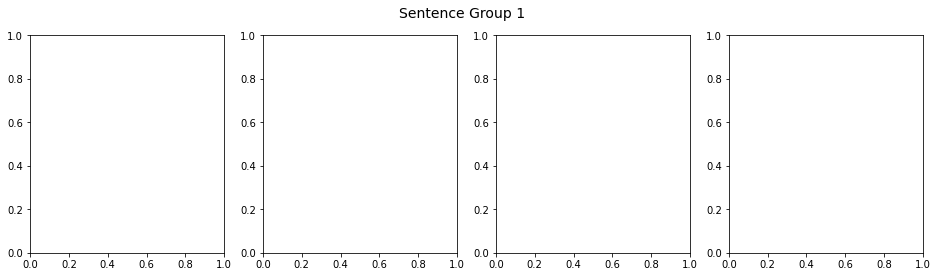

In [3]:
## GPT2
df = pd.read_csv("../data/model_outputs/gpt2_pilot_object_gaps_stimuli_with_surprisals.csv")
data.plot_metrics(df, surprisal_type='local_continuation_only', gap_type='object')